# Clinical Strand — Data Exploration

**MultimodalAI‧26 · Clinical Demo**

---

Profile the patient dataset. By the end, you should understand:
- Who is in this dataset and which subgroups are at highest risk
- Why clinical notes are Missing Not At Random (MNAR)
- Why blood loss missingness is also MNAR
- Which subgroups are most at risk of being under-served by the models

**Sections**
1. Setup & Load Data
2. Patient Demographics & Severity
3. Clinical Notes — MNAR Analysis
4. Data Profile Verdict

---
## Section 1 — Setup & Load Data

The dataset contains **500 ICU patients, one row per patient** (tabular.csv).

Primary outcome: `major_complication_30d` (1 = major complication within 30 days, ~25%).

Key modalities:
- **Demographics**: age, sex, surgery type, admission urgency
- **Severity**: SOFA score, ASA class
- **Vital signs aggregates**: heart rate, respiratory rate, SpO₂, blood pressure, temperature
- **Laboratory values**: lactate, creatinine, WBC, bilirubin
- **Clinical notes**: NLP-derived risk score (MNAR — missing for ~31% of patients)
- **Blood loss**: intra-operative blood loss (MNAR — missing for ~34% of patients)

In [24]:
%pip install -r  ../requirements.txt

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

warnings.filterwarnings('ignore')

CWD = Path.cwd().resolve()
ROOT = None
for candidate in [CWD, *CWD.parents]:
    if (candidate / 'data').exists() and (candidate / 'models').exists():
        ROOT = candidate
        break
if ROOT is None:
    raise FileNotFoundError('Could not find clinical_strand root. Run from notebooks/ or clinical_strand/.')

RAW_DATA = ROOT / 'data' / 'raw' / 'tabular.csv'
if not RAW_DATA.exists():
    raise FileNotFoundError(f'{RAW_DATA} not found. Data files are pre-included in the repository.')
print(f'Loading from: {RAW_DATA}')

Loading from: /Users/pu22650/work/mmai26-hackathon/demo/data/raw/tabular.csv


In [2]:
df = pd.read_csv(RAW_DATA)
print(f'Shape: {df.shape}')
print(f'\nKey statistics:')
print(f'  Complication rate (30d) : {df["major_complication_30d"].mean():.1%}')
print(f'  Deterioration rate (24h): {df["deteriorated_24h"].mean():.1%}')
print(f'  Patients with notes     : {df["has_notes"].mean():.1%}')
print(f'  Blood loss MNAR         : {df["blood_loss_missing"].mean():.1%}')
print(f'  Age mean / std          : {df["age"].mean():.1f} / {df["age"].std():.1f}')
print(f'  SOFA mean / std         : {df["sofa_score"].mean():.1f} / {df["sofa_score"].std():.1f}')
print(f'\nSurgery type breakdown:')
print(df['surgery_type'].value_counts().to_string())

Shape: (500, 37)

Key statistics:
  Complication rate (30d) : 25.4%
  Deterioration rate (24h): 40.8%
  Patients with notes     : 68.8%
  Blood loss MNAR         : 33.8%
  Age mean / std          : 62.7 / 13.9
  SOFA mean / std         : 6.8 / 3.3

Surgery type breakdown:
surgery_type
abdominal      155
orthopaedic    140
cardiac        112
vascular        93


---
## Section 2 — Patient Demographics & Severity

Three splits matter for the deployment verdict:
- **Age band**: elderly patients (75+) show blunted physiological responses — heart rate
  may not rise even under haemodynamic stress (beta-blockade, age-related attenuation).
- **Surgery type**: cardiac and vascular carry the highest complication rates. Vascular
  patients receive post-operative beta-blockade which masks vital sign changes.
- **SOFA score**: the primary clinical severity marker. Model failures at extreme SOFA
  scores are a governance risk.

In [27]:
df['age_band'] = pd.cut(
    df['age'],
    bins=[0, 64, 74, 200],
    labels=['under 65', '65–74', '75+']
)

print('Complication rate by age band:')
print(
    df.groupby('age_band')['major_complication_30d']
    .agg(['mean', 'count']).rename(columns={'mean': 'rate'})
    .round(3).to_string()
)
print()
print('Complication rate by surgery type:')
print(
    df.groupby('surgery_type')['major_complication_30d']
    .agg(['mean', 'count']).rename(columns={'mean': 'rate'})
    .sort_values('rate', ascending=False).round(3).to_string()
)

Complication rate by age band:
           rate  count
age_band              
under 65  0.209    273
65–74     0.300    130
75+       0.320     97

Complication rate by surgery type:
               rate  count
surgery_type              
cardiac       0.616    112
vascular      0.258     93
abdominal     0.161    155
orthopaedic   0.064    140


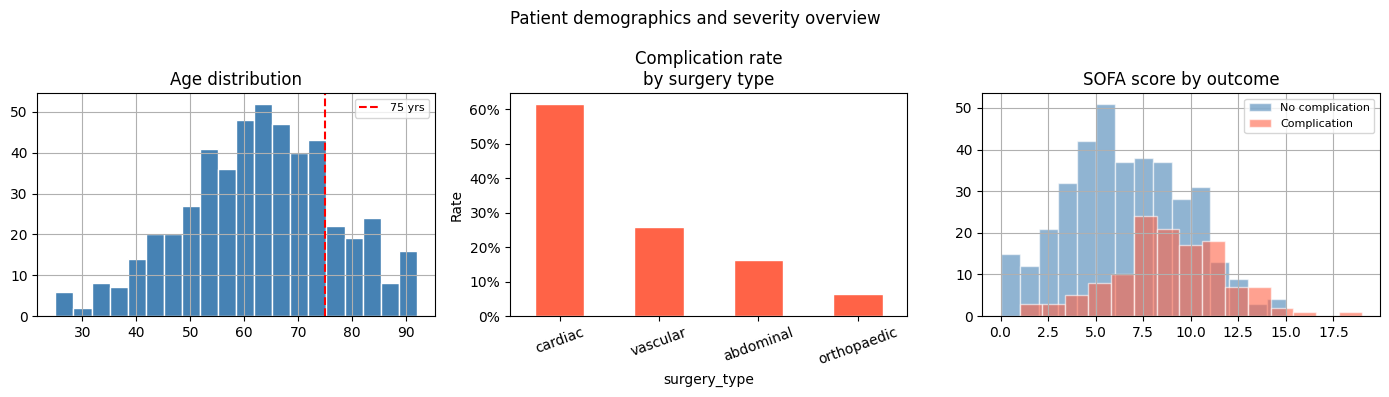

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df['age'].hist(ax=axes[0], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(75, color='red', linestyle='--', linewidth=1.5, label='75 yrs')
axes[0].set_title('Age distribution'); axes[0].legend(fontsize=8)

comp_by_surg = df.groupby('surgery_type')['major_complication_30d'].mean().sort_values(ascending=False)
comp_by_surg.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Complication rate\nby surgery type')
axes[1].set_ylabel('Rate'); axes[1].tick_params(axis='x', rotation=20)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))

for val, colour, label in [(0, 'steelblue', 'No complication'), (1, 'tomato', 'Complication')]:
    df[df['major_complication_30d'] == val]['sofa_score'].hist(
        ax=axes[2], bins=15, alpha=0.6, color=colour, edgecolor='white', label=label
    )
axes[2].set_title('SOFA score by outcome'); axes[2].legend(fontsize=8)

plt.suptitle('Patient demographics and severity overview', fontsize=12)
plt.tight_layout(); plt.show()

---
## Section 3 — Clinical Notes: MNAR Analysis

Clinical notes (`note_risk_score`) are missing for ~**31% of patients**.
This missingness is **not random** — it is Missing Not At Random (MNAR).

Note absence is driven by workload and case complexity:
- Cardiac surgery: highest missing rate (~58%)
- Vascular: second highest (~42%)
- Patients without notes have **higher risk** — the sickest are least documented

**Model A** uses note text as a primary modality. When notes are absent, the text branch
receives a zero vector, causing systematic underestimation of risk for note-absent patients —
concentrated in complex cardiac/vascular cases.

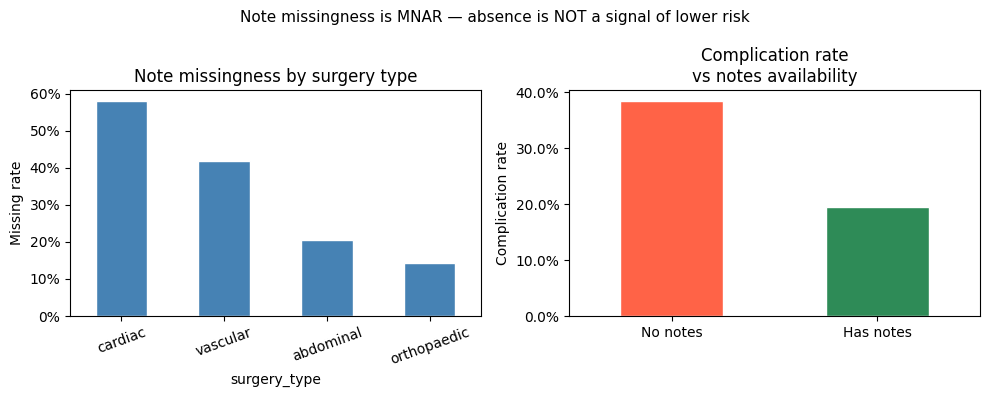

Note missingness by surgery type:
  cardiac       : 58.0% missing
  vascular      : 41.9% missing
  abdominal     : 20.6% missing
  orthopaedic   : 14.3% missing

Complication WITHOUT notes: 38.5%
Complication WITH notes:    19.5%


In [29]:
miss_by_surg = df.groupby('surgery_type')['note_risk_score'].apply(
    lambda x: x.isnull().mean()).rename('missing_rate')
comp_by_notes = df.groupby('has_notes')['major_complication_30d'].mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

miss_by_surg.sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Note missingness by surgery type')
axes[0].set_ylabel('Missing rate')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0].tick_params(axis='x', rotation=20)

comp_by_notes.index = ['No notes', 'Has notes']
comp_by_notes.plot(kind='bar', ax=axes[1], color=['tomato', 'seagreen'], edgecolor='white')
axes[1].set_title('Complication rate\nvs notes availability')
axes[1].set_ylabel('Complication rate')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Note missingness is MNAR — absence is NOT a signal of lower risk', fontsize=11)
plt.tight_layout(); plt.show()

print('Note missingness by surgery type:')
for surg, rate in miss_by_surg.sort_values(ascending=False).items():
    print(f'  {surg:14s}: {rate:.1%} missing')
print()
print(f'Complication WITHOUT notes: {comp_by_notes["No notes"]:.1%}')
print(f'Complication WITH notes:    {comp_by_notes["Has notes"]:.1%}')

---
## Section 4 — Data Profile Verdict

Answer these questions before running the app. Your answers inform the deployment
verdicts in the Submission Form in the app.

---

### 4.1 — Note Missingness (Model A MNAR)

*Which surgery type has the worst note missingness? What does this mean for a model
that uses notes as a primary signal? Is note absence a signal of lower risk?*


# Preprocessing & Split

---

Preprocess the tabular data and create stratified train/val/test splits.
The processed CSVs are used by the Model Training section below in this merged notebook.

**Prerequisite:** `data/raw/tabular.csv` must exist — it is pre-included in the repository.

**Sections**
1. Setup & Load Data
2. Imputation
3. Train / Val / Test Split
4. Verify Split
5. Save Processed CSVs

---
## Section 1 — Setup & Load Data

In [32]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

CWD = Path.cwd().resolve()
ROOT = None
for candidate in [CWD, *CWD.parents]:
    if (candidate / 'data').exists() and (candidate / 'models').exists():
        ROOT = candidate
        break
if ROOT is None:
    raise FileNotFoundError('Could not find clinical_strand root.')

RAW_DATA = ROOT / 'data' / 'raw' / 'tabular.csv'
PROC_DIR = ROOT / 'data' / 'processed'

TARGET = 'major_complication_30d'
print(f'ROOT: {ROOT}')

ROOT: C:\Users\cmanj\cmanex\ukomain\hackathon-2026\clinical\demo


In [33]:
df = pd.read_csv(RAW_DATA)
print(f'Shape: {df.shape}')
print(f'Complication rate: {df[TARGET].mean():.1%}')
print(f'Has notes:         {df["has_notes"].mean():.1%}')
print(f'Blood loss MNAR:   {df["blood_loss_missing"].mean():.1%}')
print()
print('Missing values (columns with any NaN):')
miss = df.isnull().sum()
print(miss[miss > 0].to_string())

Shape: (500, 37)
Complication rate: 25.4%
Has notes:         68.8%
Blood loss MNAR:   33.8%

Missing values (columns with any NaN):
blood_loss_ml      169
note_risk_score    156


In [34]:
print('Complication rate by surgery type:')
print(df.groupby('surgery_type')[TARGET].agg(['mean', 'count']).round(3).to_string())
print()
print('Complication rate by notes availability:')
print(df.groupby('has_notes')[TARGET].agg(['mean', 'count']).round(3).to_string())

Complication rate by surgery type:
               mean  count
surgery_type              
abdominal     0.161    155
cardiac       0.616    112
orthopaedic   0.064    140
vascular      0.258     93

Complication rate by notes availability:
            mean  count
has_notes              
0          0.385    156
1          0.195    344


---
## Section 2 — Imputation

Model classes handle `note_risk_score` and `blood_loss_imputed` internally.
For remaining NaN values in numeric columns, apply median imputation.

> **Note:** `blood_loss_ml` NaNs are intentional MNAR — do not impute here.
> The models use `blood_loss_imputed` (pre-computed) and `blood_loss_missing` (flag).
> `note_risk_score` is also left as-is — each model handles it internally.

In [35]:
numeric_cols = [
    'hr_mean', 'hr_std', 'rr_mean', 'rr_std',
    'spo2_mean', 'spo2_min', 'sbp_mean', 'temp_mean',
    'icu_lactate', 'icu_creatinine', 'icu_wbc', 'icu_bilirubin',
    'preop_creatinine', 'preop_wbc', 'preop_lactate',
]

to_impute = [c for c in numeric_cols if c in df.columns and df[c].isnull().sum() > 0]
for col in to_impute:
    df[col] = df[col].fillna(df[col].median())

if to_impute:
    print(f'Applied median imputation to: {to_impute}')
else:
    print('No NaN in numeric feature columns — no imputation needed.')

skip_cols = ['note_risk_score', 'blood_loss_ml']
remaining = df.drop(columns=[c for c in skip_cols if c in df.columns]).isnull().sum().sum()
print(f'Remaining NaN (excl. MNAR columns): {remaining}')

No NaN in numeric feature columns — no imputation needed.
Remaining NaN (excl. MNAR columns): 0


---
## Section 3 — Train / Val / Test Split

Stratified split on `major_complication_30d` to preserve class balance across folds.
For 500 patients, 70/15/15 gives roughly 350 train, 75 val, 75 test.

> **Leakage note:** imputation statistics are computed on the full dataset here for
> simplicity. A stricter approach would compute on train only then apply to val/test.
> For 500 patients the difference is negligible, but the principle matters for production.

In [36]:
from sklearn.model_selection import train_test_split

SEED = 42
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15

df_train, df_temp = train_test_split(
    df, test_size=1 - TRAIN_FRAC, stratify=df[TARGET], random_state=SEED
)
val_share = VAL_FRAC / (1 - TRAIN_FRAC)
df_val, df_test = train_test_split(
    df_temp, test_size=1 - val_share, stratify=df_temp[TARGET], random_state=SEED
)

for split, name in [(df_train, 'train'), (df_val, 'val'), (df_test, 'test')]:
    print(f'{name:6s}: n={len(split):4d}  '
          f'complication={split[TARGET].mean():.1%}  '
          f'notes={split["has_notes"].mean():.1%}')

PROC_DIR.mkdir(parents=True, exist_ok=True)
df_train.to_csv(PROC_DIR / 'train.csv', index=False)
df_val.to_csv(PROC_DIR / 'val.csv', index=False)
df_test.to_csv(PROC_DIR / 'test.csv', index=False)
print(f"Saved to {PROC_DIR}:")
print(f"  train.csv ({len(df_train)} rows)")
print(f"  val.csv   ({len(df_val)} rows)")
print(f"  test.csv  ({len(df_test)} rows)")

train : n= 349  complication=25.5%  notes=70.2%
val   : n=  75  complication=25.3%  notes=68.0%
test  : n=  76  complication=25.0%  notes=63.2%
Saved to C:\Users\cmanj\cmanex\ukomain\hackathon-2026\clinical\demo\data\processed:
  train.csv (349 rows)
  val.csv   (75 rows)
  test.csv  (76 rows)


# Model Training

---

Trains **Model A** (PyKale multimodal fusion: tabular + clinical notes text + hourly vitals time series).

**Prerequisites:**
- [ ] `data/processed/train.csv`, `val.csv`, `test.csv` — run Preprocess and split above`
- [ ] `data/raw/notes.csv`, `vitals_series.csv` — pre-included in the repository

**Sections**
1. Setup & Load Data
2. Train Model A — PyKale multimodal fusion (notes MNAR preview)
3. MNAR Analysis
4. Save Model
5. Launch App

---
## Section 1 — Setup & Load Data

In [37]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings('ignore')

CWD = Path.cwd().resolve()
ROOT = None
for candidate in [CWD, *CWD.parents]:
    if (candidate / 'models').exists() and (candidate / 'src').exists() and (candidate / 'data').exists():
        ROOT = candidate
        break
if ROOT is None:
    raise FileNotFoundError('Could not locate clinical_strand root.')

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

PROC_DIR   = ROOT / 'data' / 'processed'
RAW_DIR    = ROOT / 'data' / 'raw'
MODEL_DIR  = ROOT / 'saved_models'
METRIC_DIR = ROOT / 'saved_metrics'
TARGET     = 'major_complication_30d'


print(f'ROOT: {ROOT}')

ROOT: C:\Users\cmanj\cmanex\ukomain\hackathon-2026\clinical\demo


In [38]:
# Load processed splits
for fname in ['train.csv', 'val.csv', 'test.csv']:
    if not (PROC_DIR / fname).exists():
        raise FileNotFoundError(
            f'{fname} not found. Run the Preprocessing & Split section in this notebook first.'
        )

df_train = pd.read_csv(PROC_DIR / 'train.csv')
df_val   = pd.read_csv(PROC_DIR / 'val.csv')
df_test  = pd.read_csv(PROC_DIR / 'test.csv')

y_train = df_train[TARGET].values
y_val   = df_val[TARGET].values
y_test  = df_test[TARGET].values

print('Splits loaded:')
for split, name in [(df_train, 'train'), (df_val, 'val'), (df_test, 'test')]:
    print(f'  {name:6s}: n={len(split):4d}  complication={split[TARGET].mean():.1%}')

Splits loaded:
  train : n= 349  complication=25.5%
  val   : n=  75  complication=25.3%
  test  : n=  76  complication=25.0%


In [39]:
# Load notes and vitals — needed for Model A
notes_df  = pd.read_csv(RAW_DIR / 'notes.csv')
vitals_df = pd.read_csv(RAW_DIR / 'vitals_series.csv')

# Align modality files to each split by patient_id
train_notes  = notes_df[notes_df['patient_id'].isin(df_train['patient_id'])].reset_index(drop=True)
val_notes    = notes_df[notes_df['patient_id'].isin(df_val['patient_id'])].reset_index(drop=True)
test_notes   = notes_df[notes_df['patient_id'].isin(df_test['patient_id'])].reset_index(drop=True)

train_vitals = vitals_df[vitals_df['patient_id'].isin(df_train['patient_id'])].reset_index(drop=True)
val_vitals   = vitals_df[vitals_df['patient_id'].isin(df_val['patient_id'])].reset_index(drop=True)
test_vitals  = vitals_df[vitals_df['patient_id'].isin(df_test['patient_id'])].reset_index(drop=True)

print(f'Notes loaded  : {len(notes_df)} records (patients with has_notes == 1)')
print(f'Vitals loaded : {len(vitals_df)} records (24 rows per patient)')

Notes loaded  : 344 records (patients with has_notes == 1)
Vitals loaded : 12000 records (24 rows per patient)


In [40]:
from models.model_a import ModelA

# Check if evaluate.py is available for richer metrics
_EVAL_READY = False
try:
    from src.evaluate import compute_metrics
    _test = compute_metrics(np.array([0, 1, 0, 1]), np.array([0.1, 0.9, 0.2, 0.8]))
    assert 'auroc' in _test
    _EVAL_READY = True
    print('src/evaluate.py: ready')
except Exception as e:
    print(f'src/evaluate.py: {e}')

src/evaluate.py: ready


---
## Section 2 — Train Model A (PyKale Multimodal Fusion)

**Model A** is a three-modality fusion network (PyKale 0.2.0):
- **Tabular branch**: surgical context + ICU severity (FCNet encoder)
- **Text branch**: TF-IDF on free-text clinical notes (FCNet encoder)
- **Time series branch**: slope/variability features from hourly vitals (FCNet encoder)

**Known limitation:** when notes are absent (MNAR ~32%), the text branch receives
a zero vector, causing systematic underestimation of risk for note-absent patients —
concentrated in complex cardiac/vascular cases.

Training takes ~30–60 seconds on CPU.

In [41]:
model_a = ModelA()
model_a.fit(df_train, y_train, notes_df=train_notes, vitals_df=train_vitals)

prob_a_val = model_a.predict_proba_full(df_val, val_notes, val_vitals)[:, 1]

if _EVAL_READY:
    m_a = compute_metrics(y_val, prob_a_val, model_name='Model A')
    print(f'Model A | Val AUROC={m_a["auroc"]:.3f}  '
          f'Sensitivity={m_a["sensitivity"]:.3f}  '
          f'Brier={m_a["brier_score"]:.3f}')
else:
    from sklearn.metrics import roc_auc_score
    print(f'Model A | Val AUROC={roc_auc_score(y_val, prob_a_val):.3f}')

Model A | Val AUROC=0.777  Sensitivity=0.579  Brier=0.157


**Expected output — Model A training:**

```
Model A | Val AUROC=0.83–0.89  Sensitivity=0.55–0.75  Brier=0.13–0.17
```

Training takes ~30–60 seconds on CPU (PyKale neural network). Exact values vary with random seed.

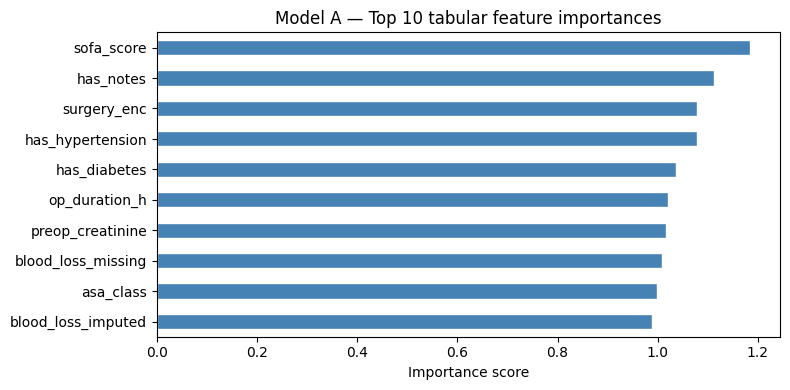

In [42]:
fi_a = model_a.feature_importance().head(10)
fig, ax = plt.subplots(figsize=(8, 4))
fi_a.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Model A — Top 10 tabular feature importances')
ax.set_xlabel('Importance score')
plt.tight_layout(); plt.show()

---
## Section 3 — MNAR Analysis

Model A's text branch receives a zero vector when clinical notes are absent.
Notes are MNAR (~32% of patients, concentrated in cardiac/vascular emergency cases).
The MNAR gap — AUROC with notes minus AUROC without — is a key evidence finding.

In [43]:
# MNAR preview: compare Model A performance for patients with vs without notes
if _EVAL_READY:
    print('Model A MNAR preview — notes subgroup:')
    for has, label in [(1, 'With notes   '), (0, 'Without notes')]:
        mask = df_val['has_notes'].values == has
        if mask.sum() < 5:
            continue
        m = compute_metrics(y_val[mask], prob_a_val[mask])
        print(f'  {label}: AUROC={m["auroc"]:.3f}  Sensitivity={m["sensitivity"]:.3f}  n={m["n_total"]}')

    no_mask  = df_val['has_notes'].values == 0
    yes_mask = df_val['has_notes'].values == 1
    if no_mask.sum() > 5 and yes_mask.sum() > 5:
        gap = (compute_metrics(y_val[yes_mask], prob_a_val[yes_mask])['auroc'] -
               compute_metrics(y_val[no_mask],  prob_a_val[no_mask])['auroc'])
        print(f'  AUROC gap (with minus without notes): {gap:.3f}')
        if gap > 0.05:
            print('  >>> MNAR signal detected. Report this in your evidence dashboard.')
else:
    print('MNAR preview skipped — evaluate.py not available.')

Model A MNAR preview — notes subgroup:
  With notes   : AUROC=0.698  Sensitivity=0.333  n=51
  Without notes: AUROC=0.900  Sensitivity=0.800  n=24
  AUROC gap (with minus without notes): -0.202


---
## Section 4 — Save Model


In [45]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(model_a, MODEL_DIR / 'model_a.joblib')
print(f'Model saved to {MODEL_DIR}/model_a.joblib')

Model saved to C:\Users\cmanj\cmanex\ukomain\hackathon-2026\clinical\demo\saved_models/model_a.joblib


In [46]:
if _EVAL_READY:
    val_results = [compute_metrics(y_val, prob_a_val, model_name='Model A')]
    summary_cols = ['model', 'auroc', 'auprc', 'sensitivity', 'brier_score']
    print('Validation summary:')
    print(pd.DataFrame(val_results)[summary_cols].to_string(index=False))
else:
    from sklearn.metrics import roc_auc_score
    print(f'Model A AUROC: {roc_auc_score(y_val, prob_a_val):.3f}')

Validation summary:
  model  auroc  auprc  sensitivity  brier_score
Model A 0.7773 0.5812       0.5789       0.1572


---
## Section 5 — Launch App

Model saved to `saved_models/model_a.joblib`. The app loads this saved model and evaluates it on the held-out test set — it does **not** re-train.

```bash
streamlit run app.py
```

The app shows live evaluation metrics in the **Evidence Dashboard** and provides a **Submission Form** to fill governance fields and save `reference/omaib_pathway.json` and `reference/model_safety_report.json`.

In [47]:
print('Training complete.')
if _EVAL_READY and 'val_results' in dir():
    for r in val_results:
        print(f'  {r["model"]}: AUROC={r["auroc"]:.3f}')
print()
print('Launch app: streamlit run app.py')

Training complete.
  Model A: AUROC=0.777

Launch app: streamlit run app.py
